In [1]:
# [Markdown]
# # 📈 Lab 04: Vectorized Walk-Forward Validation
# **Objective:** Simulate the end-to-end production pipeline.
# - Load the pristine tensor and both models (Transformer & CatBoost).
# - Generate directional predictions (Alpha).
# - Apply the Risk Veto (Meta-Labeler).
# - Calculate institutional metrics: Sharpe Ratio, Max Drawdown, and Win Rate.
# - Compare the "Unfiltered" strategy vs the "Meta-Filtered" strategy.

import os
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import joblib
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('dark_background')

# Re-define Quantformer for inference
# Re-define Quantformer for inference (MUST MATCH Notebook 02 exactly)
class Quantformer(nn.Module):
    def __init__(self, num_features, d_model=64, nhead=4, num_layers=2):
        super().__init__()
        self.proj = nn.Linear(num_features, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model*2, 
            batch_first=True, dropout=0.2
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.fc = nn.Sequential(
            nn.Linear(d_model, 32), 
            nn.ReLU(), 
            nn.Dropout(0.2), 
            nn.Linear(32, 1)
        )
        
    def forward(self, x):
        return self.fc(self.transformer(self.proj(x))[:, -1, :])

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"⚡ Compute Device: {device}")

⚡ Compute Device: mps


In [2]:
# [Markdown]
# ### 1. Load the Environment
# We load the exact artifacts that `live_trader.py` will use.

save_dir = '../data/processed/'
models_dir = '../models/'

# Load Tensor
df = pd.read_parquet(os.path.join(save_dir, 'clean_tensor.parquet')).dropna()

# Load Alpha Artifacts
scaler = joblib.load(os.path.join(save_dir, 'core_scaler.pkl'))
pca = joblib.load(os.path.join(save_dir, 'core_pca.pkl'))
tech_features = joblib.load(os.path.join(save_dir, 'core_features.pkl'))
macro_cols = [c for c in df.columns if c.startswith('macro_emb_')]

alpha_model = Quantformer(num_features=len(tech_features) + 8).to(device)
alpha_model.load_state_dict(torch.load(os.path.join(save_dir, 'core_quantformer.pth'), map_location=device))
alpha_model.eval()

# Load Risk Artifacts
meta_model = CatBoostClassifier()
meta_model.load_model(os.path.join(models_dir, 'meta_model.cbm'))

print(f"✅ Data & Models Loaded successfully. Bars to process: {len(df)}")

✅ Data & Models Loaded successfully. Bars to process: 99987


In [6]:
# [Markdown]
# ### 2. The Vectorized Signal Engine
# 1. Ask Transformer for direction.
# 2. Ask CatBoost for permission.

# --- ALPHA INFERENCE ---
macro_pca = pca.transform(df[macro_cols])
X_raw = np.hstack([df[tech_features].values, macro_pca])
X_scaled = scaler.transform(X_raw)

SEQ_LEN = 32
probabilities = np.full(len(df), np.nan)

print("🧠 Generating Alpha Signals (Transformer)...")
with torch.no_grad():
    for i in range(SEQ_LEN, len(df)):
        x_seq = X_scaled[i - SEQ_LEN : i]
        tensor_input = torch.tensor(x_seq, dtype=torch.float32).unsqueeze(0).to(device)
        logit = alpha_model(tensor_input)
        probabilities[i] = torch.sigmoid(logit).item()

df['alpha_prob'] = probabilities

# Define Active Setups (Conviction thresholds)
df['base_signal'] = np.select(
    [df['alpha_prob'] > 0.65, df['alpha_prob'] < 0.35],
    [1, -1], # 1 = LONG, -1 = SHORT
    default=0
)

# --- META INFERENCE (Risk Veto) ---
print("🛡️ Generating Risk Vetoes (CatBoost)...")
meta_features = tech_features + ['active_session_name']

# We only ask CatBoost to evaluate bars where the Transformer actually wants to trade
active_mask = df['base_signal'] != 0

X_meta = df.loc[active_mask, meta_features].copy()
X_meta['active_session_name'] = X_meta['active_session_name'].astype(str)

# Get Probability of Success
meta_probs = meta_model.predict_proba(X_meta)[:, 1] # Probability of Class 1 (Success)

# Map back to main dataframe
df['meta_prob'] = 0.0
df.loc[active_mask, 'meta_prob'] = meta_probs

# 🛡️ THE VETO LOGIC: If CatBoost thinks success prob is < 50%, we force the signal to 0
df['filtered_signal'] = np.where(df['meta_prob'] >= 0.50, df['base_signal'], 0)

print(f"Total Base Trades Proposed: {(df['base_signal'] != 0).sum()}")
print(f"Total Trades Approved by Risk Officer: {(df['filtered_signal'] != 0).sum()}")

🧠 Generating Alpha Signals (Transformer)...
🛡️ Generating Risk Vetoes (CatBoost)...
Total Base Trades Proposed: 49417
Total Trades Approved by Risk Officer: 4390


In [7]:
# [Markdown]
# ### 3. Calculate Returns & Drawdowns (Position State Vectorization)
# We track the 1-bar forward return to avoid overlapping leverage explosion. 
# Transaction costs are only applied when the position changes (Turnover).

# 1. Calculate price ratio
price_ratio = df['close'].shift(-1) / df['close']

# 2. Prevent log(0) by replacing 0.0 with NaN, then take log
df['fwd_1bar_ret'] = np.log(price_ratio.replace(0, np.nan))

# 3. Clean up any resulting NaNs or Infs (treat bad data gaps as 0% return)
df['fwd_1bar_ret'] = df['fwd_1bar_ret'].replace([np.inf, -np.inf], np.nan).fillna(0)


TRANSACTION_COST = 0.00005 # Approx 0.5 pips friction

# 1. Unfiltered Strategy (Transformer Only)
# We capture the next 15m return if our signal is active
df['strat_ret_unfiltered'] = df['base_signal'] * df['fwd_1bar_ret']

# Apply transaction costs ONLY when the position changes state
df['unfiltered_turnover'] = df['base_signal'].diff().abs() > 0
df.loc[df['unfiltered_turnover'], 'strat_ret_unfiltered'] -= TRANSACTION_COST

# 2. Meta-Filtered Strategy (Transformer + CatBoost)
df['strat_ret_filtered'] = df['filtered_signal'] * df['fwd_1bar_ret']

# Costs for filtered strategy
df['filtered_turnover'] = df['filtered_signal'].diff().abs() > 0
df.loc[df['filtered_turnover'], 'strat_ret_filtered'] -= TRANSACTION_COST

# 3. Buy & Hold (Benchmark) - Must also be the 1-bar return
df['bnh_return'] = df['fwd_1bar_ret']

# Clean up to prevent any numerical anomalies before cumsum
for col in ['strat_ret_unfiltered', 'strat_ret_filtered', 'bnh_return']:
    df[col] = df[col].replace([np.inf, -np.inf], 0).fillna(0)

# Cumulative Returns (Safe from Infinity overflow)
df['cum_unfiltered'] = np.exp(df['strat_ret_unfiltered'].cumsum()) - 1
df['cum_filtered'] = np.exp(df['strat_ret_filtered'].cumsum()) - 1
df['cum_bnh'] = np.exp(df['bnh_return'].cumsum()) - 1

# Helper for Drawdown
def calc_max_dd(cum_returns):
    high_water_mark = cum_returns.cummax()
    drawdown = cum_returns - high_water_mark
    return drawdown.min()

print("📊 SIMULATION COMPLETE. Generating plot...")

📊 SIMULATION COMPLETE. Generating plot...


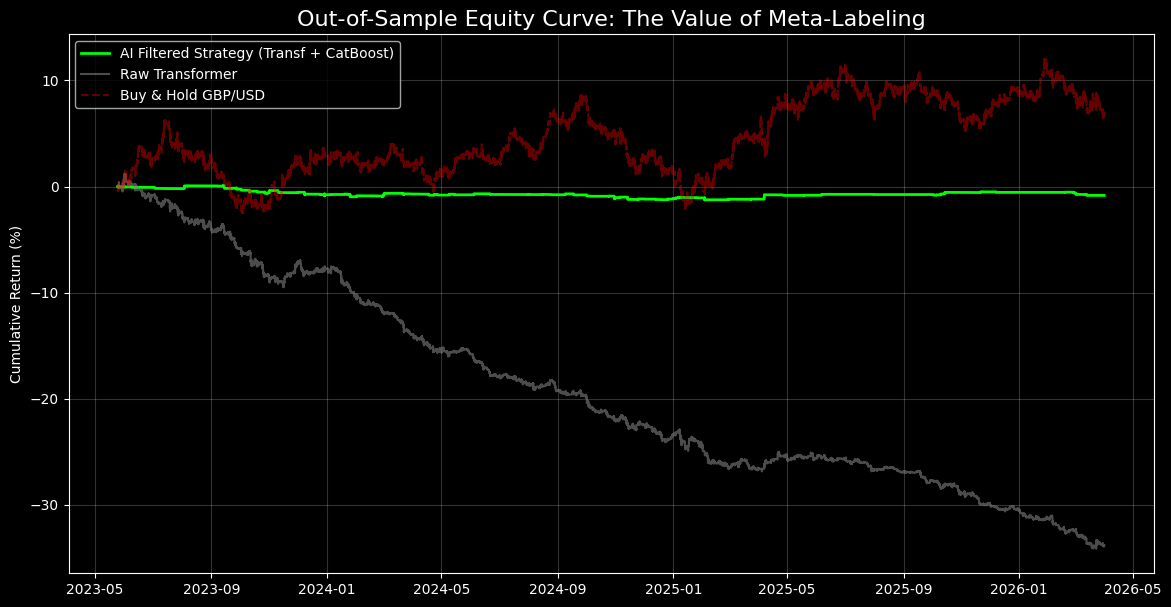

,Raw Transformer,AI Filtered (Production)
Total Trades,49417.00,4390.00
Win Rate (%),21.10,1.78
Total Return (%),-33.82,-0.84
Max Drawdown (%),-35.35,-1.36
Sharpe Ratio,-3.22,-0.44


In [8]:
# [Markdown]
# ### 4. Performance Tear Sheet

# Plotting
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['cum_filtered'] * 100, label='AI Filtered Strategy (Transf + CatBoost)', color='lime', linewidth=2)
plt.plot(df.index, df['cum_unfiltered'] * 100, label='Raw Transformer', color='gray', alpha=0.6)
plt.plot(df.index, df['cum_bnh'] * 100, label='Buy & Hold GBP/USD', color='red', alpha=0.4, linestyle='--')

plt.title("Out-of-Sample Equity Curve: The Value of Meta-Labeling", fontsize=16)
plt.ylabel("Cumulative Return (%)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

# Metrics Table
def calc_sharpe(returns):
    # Annualized Sharpe (assuming 252 days, 96 15m bars per day = 24192 bars/year)
    return np.sqrt(24192) * (returns.mean() / (returns.std() + 1e-9))

metrics = {
    "Total Trades": [
        (df['base_signal'] != 0).sum(), 
        (df['filtered_signal'] != 0).sum()
    ],
    "Win Rate (%)": [
        (df[df['base_signal'] != 0]['strat_ret_unfiltered'] > 0).mean() * 100,
        (df[df['filtered_signal'] != 0]['strat_ret_filtered'] > 0).mean() * 100
    ],
    "Total Return (%)": [
        df['cum_unfiltered'].iloc[-1] * 100, 
        df['cum_filtered'].iloc[-1] * 100
    ],
    "Max Drawdown (%)": [
        calc_max_dd(df['cum_unfiltered']) * 100, 
        calc_max_dd(df['cum_filtered']) * 100
    ],
    "Sharpe Ratio": [
        calc_sharpe(df['strat_ret_unfiltered']), 
        calc_sharpe(df['strat_ret_filtered'])
    ]
}

metrics_df = pd.DataFrame(metrics, index=["Raw Transformer", "AI Filtered (Production)"]).T
display(metrics_df.round(2))